# Win Probability Model - Training Notebook

Build a machine learning model to predict the probability of the home team winning based on game situation.

## Model Specifications
- **Target**: Home team win probability (0-1)
- **Algorithm**: XGBoost Classifier
- **Features**: score_differential, time_remaining, field_position, down, distance, timeouts
- **Evaluation**: Log Loss, Brier Score, Calibration plots
- **Training Data**: Same competitive plays from 2016-2024

## Steps
1. Load and prepare data
2. Feature engineering
3. Train/test split by season
4. Train XGBoost classifier
5. Evaluate calibration and accuracy
6. Save model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, classification_report
from sklearn.calibration import calibration_curve
import xgboost as xgb
import joblib
import json
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Load Data

Load the same play-by-play data used for EPA model.

In [2]:
# Load data
data_path = Path('../data/play_by_play_2016_2024.parquet')
pbp = pd.read_parquet(data_path)

print(f"Loaded {len(pbp):,} plays")
print(f"Seasons: {sorted(pbp['season'].unique())}")
print(f"\nColumns: {pbp.shape[1]}")
pbp.head()

Loaded 435,483 plays
Seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Columns: 396


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,pass_location,air_yards,yards_after_catch,run_location,run_gap,field_goal_result,kick_distance,extra_point_result,two_point_conv_result,home_timeouts_remaining,away_timeouts_remaining,timeout,timeout_team,td_team,td_player_name,td_player_id,posteam_timeouts_remaining,defteam_timeouts_remaining,total_home_score,total_away_score,posteam_score,defteam_score,score_differential,posteam_score_post,defteam_score_post,score_differential_post,no_score_prob,opp_fg_prob,opp_safety_prob,opp_td_prob,fg_prob,safety_prob,td_prob,extra_point_prob,two_point_conversion_prob,ep,epa,total_home_epa,total_away_epa,total_home_rush_epa,total_away_rush_epa,total_home_pass_epa,total_away_pass_epa,air_epa,yac_epa,comp_air_epa,comp_yac_epa,total_home_comp_air_epa,total_away_comp_air_epa,total_home_comp_yac_epa,total_away_comp_yac_epa,total_home_raw_air_epa,total_away_raw_air_epa,total_home_raw_yac_epa,total_away_raw_yac_epa,wp,def_wp,home_wp,away_wp,wpa,vegas_wpa,vegas_home_wpa,home_wp_post,away_wp_post,vegas_wp,vegas_home_wp,total_home_rush_wpa,total_away_rush_wpa,total_home_pass_wpa,total_away_pass_wpa,air_wpa,yac_wpa,comp_air_wpa,comp_yac_wpa,total_home_comp_air_wpa,total_away_comp_air_wpa,total_home_comp_yac_wpa,total_away_comp_yac_wpa,total_home_raw_air_wpa,total_away_raw_air_wpa,total_home_raw_yac_wpa,total_away_raw_yac_wpa,punt_blocked,first_down_rush,first_down_pass,first_down_penalty,third_down_converted,third_down_failed,fourth_down_converted,fourth_down_failed,incomplete_pass,touchback,interception,punt_inside_twenty,punt_in_endzone,punt_out_of_bounds,punt_downed,punt_fair_catch,kickoff_inside_twenty,kickoff_in_endzone,kickoff_out_of_bounds,kickoff_downed,kickoff_fair_catch,fumble_forced,fumble_not_forced,fumble_out_of_bounds,solo_tackle,safety,penalty,tackled_for_loss,fumble_lost,own_kickoff_recovery,own_kickoff_recovery_td,qb_hit,rush_attempt,pass_attempt,sack,touchdown,pass_touchdown,rush_touchdown,return_touchdown,extra_point_attempt,two_point_attempt,field_goal_attempt,kickoff_attempt,punt_attempt,fumble,complete_pass,assist_tackle,lateral_reception,lateral_rush,lateral_return,lateral_recovery,passer_player_id,passer_player_name,passing_yards,receiver_player_id,receiver_player_name,receiving_yards,rusher_player_id,rusher_player_name,rushing_yards,lateral_receiver_player_id,lateral_receiver_player_name,lateral_receiving_yards,lateral_rusher_player_id,lateral_rusher_player_name,lateral_rushing_yards,lateral_sack_player_id,lateral_sack_player_name,interception_player_id,interception_player_name,lateral_interception_player_id,lateral_interception_player_name,punt_returner_player_id,punt_returner_player_name,lateral_punt_returner_player_id,lateral_punt_returner_player_name,kickoff_returner_player_name,kickoff_returner_player_id,lateral_kickoff_returner_player_id,lateral_kickoff_returner_player_name,punter_player_id,punter_player_name,kicker_player_name,kicker_player_id,own_kickoff_recovery_player_id,own_kickoff_recovery_player_name,blocked_player_id,blocked_player_name,tackle_for_loss_1_player_id,tackle_for_loss_1_player_name,tackle_for_loss_2_player_id,tackle_for_loss_2_player_name,qb_hit_1_player_id,qb_hit_1_player_name,qb_hit_2_player_id,qb_hit_2_player_name,forced_fumble_player_1_team,forced_fumble_player_1_player_id,forced_fumble_player_1_player_name,forced_fumble_player_2_team,forced_fumble_player_2_player_id,forced_fumble_player_2_player_name,solo_tackle_1_team,solo_tackle_2_team,solo_tackle_1_player_id,solo_tackle_2_player_id,solo_tackle_1_player_name,solo_tackle_2_player_name,assist_tackle_1_player_id,assist_tackle_1_player_name,assist_tackle_1_team,assist_tack

## 2. Data Cleaning & Filtering

Apply same filters as EPA model:
- Remove non-competitive plays
- Remove plays with missing critical data
- Keep only competitive games (blowout filter)

In [3]:
# Filter to regular plays (same as EPA model)
pbp_clean = pbp[
    (pbp['play_type'].isin(['run', 'pass'])) &
    (pbp['down'].notna()) &
    (pbp['ydstogo'].notna()) &
    (pbp['yardline_100'].notna()) &
    (pbp['score_differential'].notna()) &
    (pbp['game_seconds_remaining'].notna()) &
    (pbp['posteam_timeouts_remaining'].notna()) &
    (pbp['defteam_timeouts_remaining'].notna())
].copy()

print(f"After basic filtering: {len(pbp_clean):,} plays")

# Apply blowout filter (same as EPA model)
pbp_clean['abs_score_diff'] = pbp_clean['score_differential'].abs()

competitive_mask = (
    ((pbp_clean['qtr'] == 1) & (pbp_clean['abs_score_diff'] <= 10)) |
    ((pbp_clean['qtr'] == 2) & (pbp_clean['abs_score_diff'] <= 17)) |
    ((pbp_clean['qtr'] == 3) & (pbp_clean['abs_score_diff'] <= 10)) |
    ((pbp_clean['qtr'] == 4) & (pbp_clean['abs_score_diff'] <= 21))
)

pbp_clean = pbp_clean[competitive_mask].copy()

print(f"After blowout filter: {len(pbp_clean):,} plays")
print(f"Removed {len(pbp) - len(pbp_clean):,} non-competitive plays")

After basic filtering: 309,043 plays
After blowout filter: 264,703 plays
Removed 170,780 non-competitive plays


## 3. Feature Engineering

Create features for Win Probability prediction:
- Score differential (positive = home winning)
- Time remaining (seconds)
- Field position (yardline_100)
- Down and distance
- Timeouts remaining
- Half indicator
- Red zone indicator

In [ ]:
# Create target variable: Did home team win?
# We need to aggregate by game to get final result
game_results = pbp_clean.groupby('game_id').agg({
    'home_score': 'last',
    'away_score': 'last'
}).reset_index()

game_results['home_won'] = (game_results['home_score'] > game_results['away_score']).astype(int)

# Merge back to plays
pbp_clean = pbp_clean.merge(game_results[['game_id', 'home_won']], on='game_id', how='left')

print(f"Home team win rate: {pbp_clean['home_won'].mean():.1%}")

# Feature engineering
pbp_clean['red_zone'] = (pbp_clean['yardline_100'] <= 20).astype(int)
pbp_clean['second_half'] = (pbp_clean['qtr'] >= 3).astype(int)
pbp_clean['fourth_quarter'] = (pbp_clean['qtr'] == 4).astype(int)
pbp_clean['two_minute_drill'] = (pbp_clean['game_seconds_remaining'] <= 120).astype(int)

# Determine who has possession
pbp_clean['is_home_offense'] = (pbp_clean['posteam'] == pbp_clean['home_team']).astype(int)

# CRITICAL FIX: Convert score_differential to HOME team's perspective
# In nflfastR, score_differential = posteam_score - defteam_score (from offense perspective)
# We need it from HOME perspective: positive = home winning, negative = home losing
pbp_clean['score_diff_home'] = pbp_clean.apply(
    lambda x: x['score_differential'] if x['is_home_offense'] else -x['score_differential'],
    axis=1
)

# Calculate field position from home team's perspective
# Higher value = better for home team
pbp_clean['field_position_home_perspective'] = pbp_clean.apply(
    lambda x: 100 - x['yardline_100'] if x['is_home_offense'] else x['yardline_100'],
    axis=1
)

print("\n✓ Features created")
print(f"✓ Score differential converted to home perspective")

## 4. Select Features for Model

Features for Win Probability:
1. `score_differential` - Most important factor
2. `game_seconds_remaining` - Time context
3. `field_position_home_perspective` - Field position relative to home team
4. `down` - Current down
5. `ydstogo` - Yards to first down
6. `posteam_timeouts_remaining` - Offense timeouts
7. `defteam_timeouts_remaining` - Defense timeouts
8. `red_zone` - In scoring territory
9. `fourth_quarter` - Crunch time indicator
10. `is_home_offense` - Who has the ball

In [ ]:
# Select features
feature_cols = [
    'score_diff_home',  # FIXED: Use home-perspective score differential
    'game_seconds_remaining',
    'field_position_home_perspective',
    'down',
    'ydstogo',
    'posteam_timeouts_remaining',
    'defteam_timeouts_remaining',
    'red_zone',
    'fourth_quarter',
    'is_home_offense'
]

target_col = 'home_won'

# Create feature matrix and target
X = pbp_clean[feature_cols].copy()
y = pbp_clean[target_col].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")
print(f"\nFeatures: {feature_cols}")

# Check for missing values
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠ Missing values detected:")
    print(missing[missing > 0])
else:
    print("\n✓ No missing values")

## 5. Train/Test Split

Use 2023-2024 as test set, earlier seasons for training.

In [6]:
# Split by season
test_seasons = [2023, 2024]
train_mask = ~pbp_clean['season'].isin(test_seasons)
test_mask = pbp_clean['season'].isin(test_seasons)

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {len(X_train):,} plays")
print(f"Test set: {len(X_test):,} plays")
print(f"\nTrain win rate: {y_train.mean():.1%}")
print(f"Test win rate: {y_test.mean():.1%}")

Training set: 203,877 plays
Test set: 60,826 plays

Train win rate: 53.7%
Test win rate: 54.5%


## 6. Train XGBoost Classifier

Train XGBoost model optimized for probability calibration.

In [7]:
# Train XGBoost classifier
print("Training XGBoost Win Probability model...\n")

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✓ Model training complete")

Training XGBoost Win Probability model...

[0]	validation_0-logloss:0.68666
[50]	validation_0-logloss:0.53208
[100]	validation_0-logloss:0.52884
[150]	validation_0-logloss:0.52810
[199]	validation_0-logloss:0.52839

✓ Model training complete


## 7. Model Evaluation

Evaluate model performance using classification metrics.

In [8]:
# Make predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of home team winning
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
logloss = log_loss(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
accuracy = (y_pred == y_test).mean()

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)
print(f"Log Loss:        {logloss:.4f}")
print(f"Brier Score:     {brier:.4f}")
print(f"AUC-ROC:         {auc:.4f}")
print(f"Accuracy:        {accuracy:.4f}")
print("=" * 60)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Away Win', 'Home Win']))

MODEL PERFORMANCE
Log Loss:        0.5284
Brier Score:     0.1803
AUC-ROC:         0.8005
Accuracy:        0.7146

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.69      0.67      0.68     27686
    Home Win       0.73      0.75      0.74     33140

    accuracy                           0.71     60826
   macro avg       0.71      0.71      0.71     60826
weighted avg       0.71      0.71      0.71     60826



## 8. Calibration Analysis

Check if predicted probabilities are well-calibrated.

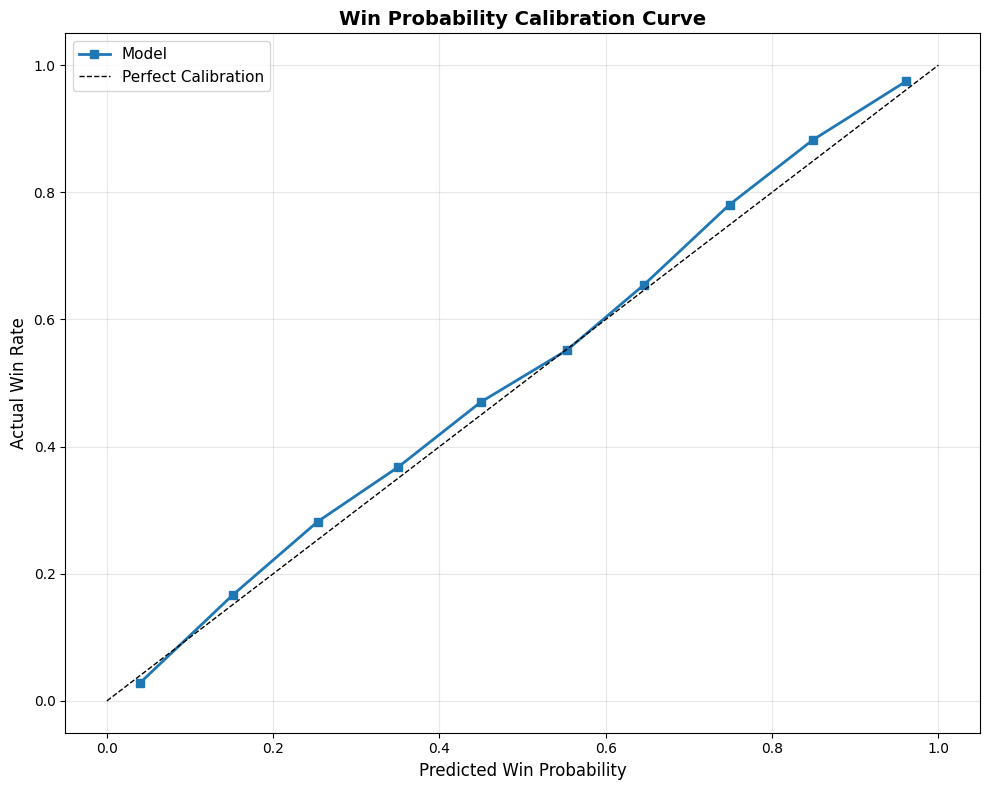

Brier Score: 0.1803 (lower is better, 0 = perfect)


In [9]:
# Calibration curve
fig, ax = plt.subplots(figsize=(10, 8))

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_pred_proba, n_bins=10
)

ax.plot(mean_predicted_value, fraction_of_positives, 's-', label='Model', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=1)

ax.set_xlabel('Predicted Win Probability', fontsize=12)
ax.set_ylabel('Actual Win Rate', fontsize=12)
ax.set_title('Win Probability Calibration Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Brier Score: {brier:.4f} (lower is better, 0 = perfect)")

## 9. Feature Importance

Analyze which features are most important for predictions.


Feature Importance:
                        feature  importance
                is_home_offense    0.588355
             score_differential    0.162960
                 fourth_quarter    0.072706
                       red_zone    0.053774
     posteam_timeouts_remaining    0.029877
         game_seconds_remaining    0.027909
field_position_home_perspective    0.019666
                           down    0.017343
     defteam_timeouts_remaining    0.016989
                        ydstogo    0.010423


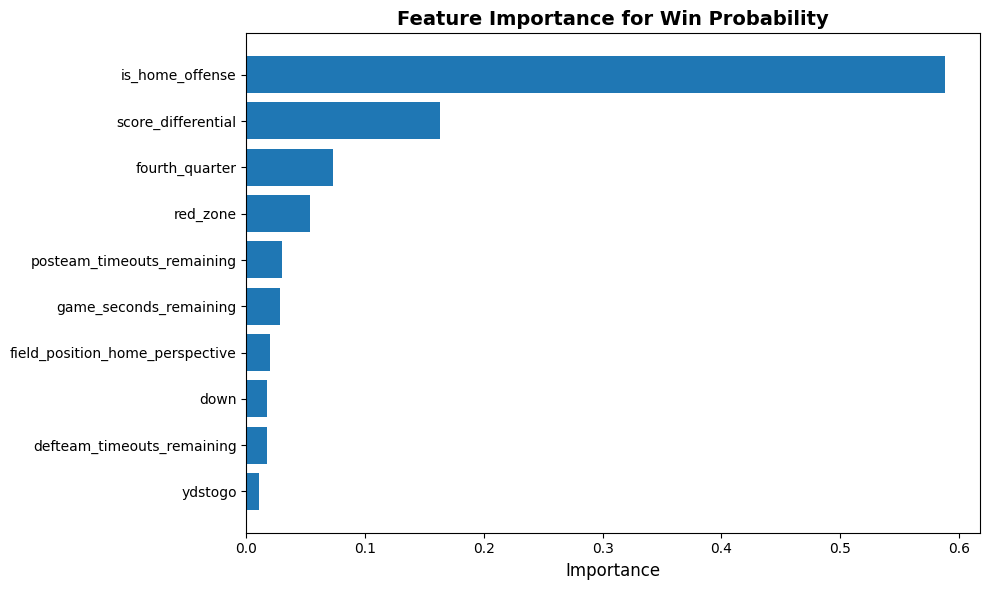

In [10]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance for Win Probability', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Test Predictions on Sample Scenarios

Verify model makes sense with realistic game situations.

In [ ]:
# Test scenarios
scenarios = [
    {
        'name': 'Close game, 2 min left, home has ball at midfield',
        'score_diff_home': 0,  # Tied game
        'game_seconds_remaining': 120,
        'field_position_home_perspective': 50,
        'down': 1,
        'ydstogo': 10,
        'posteam_timeouts_remaining': 2,
        'defteam_timeouts_remaining': 2,
        'red_zone': 0,
        'fourth_quarter': 1,
        'is_home_offense': 1
    },
    {
        'name': 'Home up 7, 5 min left, away has ball at own 25',
        'score_diff_home': 7,  # Home winning by 7
        'game_seconds_remaining': 300,
        'field_position_home_perspective': 75,  # Away at their own 25
        'down': 1,
        'ydstogo': 10,
        'posteam_timeouts_remaining': 3,
        'defteam_timeouts_remaining': 2,
        'red_zone': 0,
        'fourth_quarter': 1,
        'is_home_offense': 0
    },
    {
        'name': 'Home down 3, 10 min left, home has ball in red zone',
        'score_diff_home': -3,  # Home losing by 3
        'game_seconds_remaining': 600,
        'field_position_home_perspective': 85,  # Home at opponent's 15
        'down': 1,
        'ydstogo': 10,
        'posteam_timeouts_remaining': 3,
        'defteam_timeouts_remaining': 3,
        'red_zone': 1,
        'fourth_quarter': 1,
        'is_home_offense': 1
    },
    {
        'name': 'Home up 14, 2 min left, away has ball at own 20',
        'score_diff_home': 14,  # Home winning by 14
        'game_seconds_remaining': 120,
        'field_position_home_perspective': 80,  # Away at their own 20
        'down': 1,
        'ydstogo': 10,
        'posteam_timeouts_remaining': 0,
        'defteam_timeouts_remaining': 3,
        'red_zone': 0,
        'fourth_quarter': 1,
        'is_home_offense': 0
    }
]

print("\nTest Scenarios:")
print("=" * 80)

for scenario in scenarios:
    scenario_df = pd.DataFrame([{k: v for k, v in scenario.items() if k != 'name'}])
    scenario_df = scenario_df[feature_cols]
    
    win_prob = model.predict_proba(scenario_df)[0, 1]
    
    print(f"\n{scenario['name']}")
    print(f"  Home Win Probability: {win_prob:.1%}")
    print(f"  Away Win Probability: {1 - win_prob:.1%}")

print("\n" + "=" * 80)

## 11. Save Model

Save the trained model and metadata for API deployment.

In [12]:
# Create models directory
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save model
model_path = models_dir / 'win_probability_model_xgboost.joblib'
joblib.dump(model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save metadata
metadata = {
    'model_type': 'XGBoost Classifier',
    'features': feature_cols,
    'training_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'seasons': [int(s) for s in sorted(pbp_clean['season'].unique())],
    'train_seasons': [int(s) for s in sorted(pbp_clean[train_mask]['season'].unique())],
    'test_seasons': test_seasons,
    'performance': {
        'log_loss': float(logloss),
        'brier_score': float(brier),
        'auc_roc': float(auc),
        'accuracy': float(accuracy)
    },
    'feature_importance': {
        feature: float(importance) 
        for feature, importance in zip(importance_df['feature'], importance_df['importance'])
    }
}

metadata_path = models_dir / 'win_probability_model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata saved to: {metadata_path}")

print("\n" + "=" * 60)
print("WIN PROBABILITY MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"Model: {model_path.name}")
print(f"Training samples: {len(X_train):,}")
print(f"Log Loss: {logloss:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"Accuracy: {accuracy:.1%}")
print("=" * 60)

✓ Model saved to: ../models/win_probability_model_xgboost.joblib
✓ Metadata saved to: ../models/win_probability_model_metadata.json

WIN PROBABILITY MODEL TRAINING COMPLETE
Model: win_probability_model_xgboost.joblib
Training samples: 203,877
Log Loss: 0.5284
Brier Score: 0.1803
AUC-ROC: 0.8005
Accuracy: 71.5%
